In [98]:


from dotenv import load_dotenv
import os

load_dotenv()

key = os.getenv("SERPER_API_KEY")

print("Serper key loaded:", bool(key))
print("Key length:", len(key) if key else 0)

Serper key loaded: True
Key length: 64


In [101]:
import os
import requests
from dotenv import load_dotenv

load_dotenv(override=True)

key = os.getenv("SERPER_API_KEY")

print("Key loaded:", bool(key))
print("Key length:", len(key) if key else 0)

headers = {
    "X-API-KEY": key,
    "Content-Type": "application/json"
}

response = requests.post(
    "https://google.serper.dev/search",
    headers=headers,
    json={"q": "Python developer jobs in Bangalore"}
)

print("Status:", response.status_code)
print("Response:", response.text)

Key loaded: True
Key length: 64
Status: 403
Response: {"message":"Unauthorized.","statusCode":403}


In [83]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import Literal

In [84]:
##Coding,google_search,weather

class FlowState(BaseModel):
    question:str=Field(description="What User Asked")
    category:Literal["coding","google_search","weather"]=Field(default="google_search")
    answer:str=Field(default="")

In [85]:
#for structured Output
class QuestionCategory(BaseModel):
    category:Literal["coding","google_search","weather"]=Field(default="google_search",description="Question Category")


In [86]:
llm=ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [87]:
def check_question_category(state:FlowState)->FlowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res=st_llm.invoke(f"I want to know the category of my question,Question is {state.question} If your not sure just give 'google_search'as a category")
    state.category=res.category
    return state

In [88]:
flow=FlowState(question="What is the temperature in a india")
check_question_category(flow)

FlowState(question='What is the temperature in a india', category='weather', answer='')

In [89]:
def route(state:FlowState)->Literal["coding","google_search","weather"]:
    return state.category

In [90]:
def code_node(state:FlowState)->FlowState:
    res=llm.invoke(f"Your a coding expert:{state.question}")
    state.answer=res
    return state


def weather_node(state:FlowState)->FlowState:
    res=weather_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
    return state



def google_search_node(state:FlowState)->FlowState:
    res=google_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
    return state


In [91]:
graph=StateGraph(FlowState)


graph.add_node("check question category",check_question_category)

#node name and category needs to be same so that route can identify

graph.add_node("coding",code_node)
graph.add_node("google_search",google_search_node)
graph.add_node("weather",weather_node)


graph.add_edge(START,"check question category")
graph.add_conditional_edges("check question category",route)
graph.add_edge("coding",END)
graph.add_edge("google_search",END)
graph.add_edge("weather",END)

graph=graph.compile()

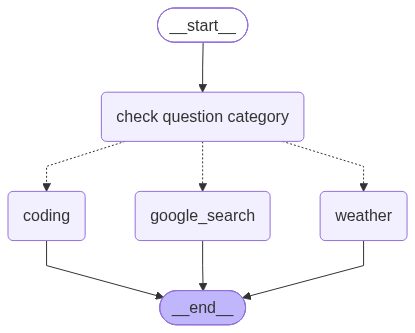

In [92]:
graph

In [93]:
res=graph.invoke({"question":"how to find the sum using python"})

In [94]:
print(res["answer"].content[0]["text"])

As a coding expert, I can tell you that finding the sum in Python is very straightforward. Depending on what you are trying to add up, there are a few different ways to do it. 

Here are the most common and efficient ways:

---

### 1. The Built-in `sum()` Function (Best for lists and iterables)
If you have a list, tuple, or set of numbers, the built-in `sum()` function is the Pythonic way to do it.

```python
numbers = [1, 2, 3, 4, 5]

total = sum(numbers)
print(total)  # Output: 15
```

* **Bonus:** You can also provide a starting value as a second argument:
  ```python
  total = sum([1, 2, 3], 10)  # Starts at 10, adds 1+2+3
  print(total)  # Output: 16
  ```

---

### 2. Summing a Few Individual Numbers
If you just have a few variables or numbers, you can use the standard `+` operator.

```python
a = 5
b = 10
c = 15

total = a + b + c
print(total)  # Output: 30
```

---

### 3. Using a `for` Loop (Great if you need custom logic)
If you need to perform some checks or modifications w

In [95]:
from langchain.agents import create_agent
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.tools import tool

In [96]:
search=GoogleSerperAPIWrapper()
tools=[search.run]

google_agent=create_agent(
    model=llm,
    tools=tools,
    system_prompt="Your an agent and search for any question on google",
)

##weather agent
@tool
def get_weather(city:str):
    """
        It provides real time weather details for any city
    """
    return f"the current temp in {city} is 23C"

weather_agent=create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="Your an agent and can provide real time weather details",
)

In [97]:
res=graph.invoke({"question":"who is pm of india"})


HTTPError: 403 Client Error: Forbidden for url: https://google.serper.dev/search?q=current+Prime+Minister+of+India&gl=us&hl=en&num=10